<p style="color:#FFF; background:#07D; padding:12px; font-size:20px; font-style:italic; text-align:center">
<span style="width:49%; display:inline-block; text-align:left">Christophe Schlick</span>
<span style="width:49%; display:inline-block; text-align:right">schlick[at]u-bordeaux.fr</span>
<span style="font-size:48px; font-style:normal"><b>EXERCICES : MATPLOTLIB</b></span><br>
<span style="width:49%; display:inline-block; text-align:left">Version 2022-10</span>
<span style="width:49%; display:inline-block; text-align:right">Licence CC-BY-NC-ND</span></p>

In [1]:
import numpy as np # import du package 'numpy' avec alias 'np'
import matplotlib.pyplot as mp # import du package 'matplotlib' avec alias 'mp'
from ipywidgets import interact, interact_manual # import des fonctions d'interaction
from SRC.tools import show # import de la fonction 'show'
mp.style.use('default') # utilisation du style 'default' pour les figures

<h2 style="padding:16px; color:#FFF; background:#07D">Exercice E1 - Approximation polynomiale</h2>

Cet exercice propose d'utiliser le module **`np.polynomial`** pour effectuer l'approximation polynomiale $P_n(x)$ d'une fonction arbitraire de la forme $y = f(x)$. En particulier, on va vérifier que pour un degré de polynôme donné, l'utilisation de la **[base polynomiale $T_n(x)$ de Chebyshev](https://fr.wikipedia.org/wiki/Polyn%C3%B4me_de_Tchebychev)** donne des biens meilleures approximations que celles fournies par la **base canonique $M_n(x)$ des monômes** (limitation du ***phénomène de Runge***). La mise en oeuvre de cette technique sera illustrée en utilisant quatre fonctions de difficulté croissante, au sens de l'approximation polynomiale :

- $f_a(x)$ : fonction affine à laquelle on rajoute une perturbation sinusoïdale de basse fréquence
- $f_b(x)$ : fonction quadratique avec une perturbation sinusoïdale de moyenne fréquence
- $f_c(x)$ : fonction $f_a(x)$ à laquelle on rajoute une perturbation aléatoire de haute fréquence
- $f_d(x)$ : fonction $f_b(x)$ avec la même perturbation aléatoire que $f_c(x)$

In [2]:
size = 200 # nombre d'échantillons utilisés pour le tracé et l'approximation des fonctions
x = np.linspace(-10, 10, size) # échantillonnage uniforme de l'intervalle de tracé [-10, 10]
fa = lambda x: 1 + 3*x + 4*np.sin(x) # fonction affine avec perturbation sinusoïdale
fb = lambda x: 25 - 0.5*x*x + 5*np.sin(2.5*x) # fonction quadratique avec perturbation sinusoïdale
noise = np.random.normal(0, 2, size) # perturbation aléatoire par échantillon (distribution normale)
fc = lambda x: fa(x) + noise # fonction fa avec perturbation aléatoire
fd = lambda x: fb(x) + noise # fonction fb avec perturbation aléatoire

---
### 1 - Affichage des fonctions de test

Pour visualiser ces fonctions avec le package **matplotlib**, on va écrire une fonction **`plot_funcs(x, funcs, title='')`** qui permet de tracer, sur une même figure, un ensemble de fonctions stockées dans un dictionnaire. Le paramètre **`x`** est un vecteur stockant les échantillons sur l'axe horizontal correspondant à l'intervalle utilisé pour le tracé des fonctions, et chaque élément du dictionnaire **`funcs`** va associer une chaîne de caractères **`name`** à une fonction universelle **`func`** qui sera appliquée au vecteur **`x`** pour obtenir les échantillons sur l'axe vertical. La chaîne **`title`** servira de titre global à la figure générée, et chacune des chaînes **`name`** sera utilisée pour identifier la courbe sur la légende correspondante.

In [3]:
def plot_funcs(x, funcs, title=''):
  """plot all functions, stored in dictionary 'funcs', computed on a vector of samples stored in 'x'"""
  # TODO

Tester la fonction **`plot_funcs`** sur les quatre fonctions de test $f_a, f_b, f_c$ et $f_d$ :

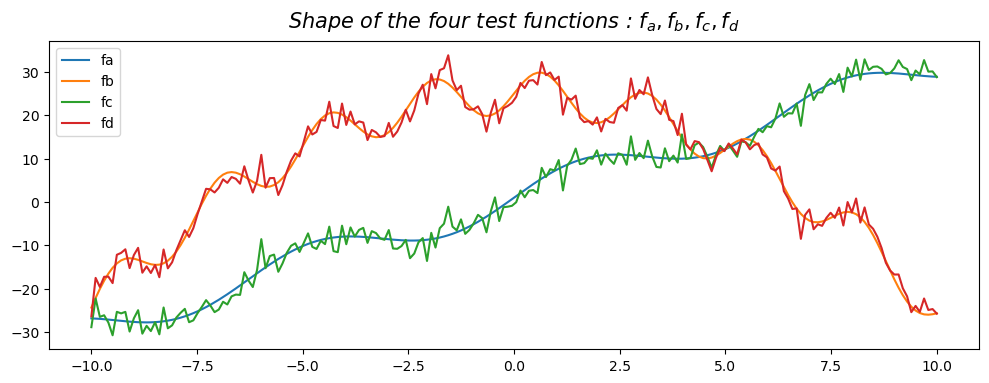

In [5]:
test_funcs = dict(fa=fa, fb=fb, fc=fc, fd=fd) # on associe chaque fonction à sa chaîne de caractères
plot_funcs(x, test_funcs, 'Shape of the four test functions : $f_a, f_b, f_c, f_d$')

---
### 2 - Base des monômes et base de Chebyshev

Le module **`polynomial`** de **numpy** contient un certain nombre de classes (au sens du paradigme de la programmation objet) correspondant à des bases polynomiales classiques. On commence donc par importer la base des monônes (classe **`Polynomial`**) et la base de Chebyshev (classe **`Chebyshev`**) en utilisant les alias classiques, **`M`** et **`T`**, respectivement :

In [6]:
from numpy.polynomial import Polynomial as M # import de la classe 'Polynomial' (base des monômes)
from numpy.polynomial import Chebyshev as T # import de la classe 'Chebyshev' (base de Chebyshev)

In [7]:
for n in range(6): # on affiche les 6 premiers polynômes de chacune des deux bases
  print(f"M_{n}(x) = {M.basis(n)}\nT_{n}(x) = {T.basis(n)}")

M_0(x) = 1.0
T_0(x) = 1.0
M_1(x) = 0.0 + 1.0 x**1
T_1(x) = 0.0 + 1.0 T_1(x)
M_2(x) = 0.0 + 0.0 x**1 + 1.0 x**2
T_2(x) = 0.0 + 0.0 T_1(x) + 1.0 T_2(x)
M_3(x) = 0.0 + 0.0 x**1 + 0.0 x**2 + 1.0 x**3
T_3(x) = 0.0 + 0.0 T_1(x) + 0.0 T_2(x) + 1.0 T_3(x)
M_4(x) = 0.0 + 0.0 x**1 + 0.0 x**2 + 0.0 x**3 + 1.0 x**4
T_4(x) = 0.0 + 0.0 T_1(x) + 0.0 T_2(x) + 0.0 T_3(x) + 1.0 T_4(x)
M_5(x) = 0.0 + 0.0 x**1 + 0.0 x**2 + 0.0 x**3 + 0.0 x**4 + 1.0 x**5
T_5(x) = 0.0 + 0.0 T_1(x) + 0.0 T_2(x) + 0.0 T_3(x) + 0.0 T_4(x) + 1.0 T_5(x)


In [8]:
for n in range(6): # on convertit les 6 premiers polynômes de Chebyshev sur la base monomiale
  print(f"T_{n}(x) = {T.basis(n).convert(kind=M)}")

T_0(x) = 1.0
T_1(x) = 0.0 + 1.0 x**1
T_2(x) = -1.0 + 0.0 x**1 + 2.0 x**2
T_3(x) = 0.0 - 3.0 x**1 + 0.0 x**2 + 4.0 x**3
T_4(x) = 1.0 + 0.0 x**1 - 8.0 x**2 + 0.0 x**3 + 8.0 x**4
T_5(x) = 0.0 + 5.0 x**1 + 0.0 x**2 - 20.0 x**3 + 0.0 x**4 + 16.0 x**5


---
### 3 - Affichage des polynômes correspondant aux deux bases

Pour mieux comprendre le comportement des polynômes $M_n(x)$ et $T_n(x)$ composant les deux bases, on va écrire une fonction **`plot_basis(basis, n=6)`** permettant de tracer les **`n`** premiers polynômes d'une base **`basis`** sur un intervalle $[-1,1]$, en appelant la fonction **`plot_funcs`** créée précédemment :

In [9]:
def plot_basis(basis, n=6):
  """plot the 'n' first terms of the provided polynomial 'basis' on range [-1,1]"""
  # TODO

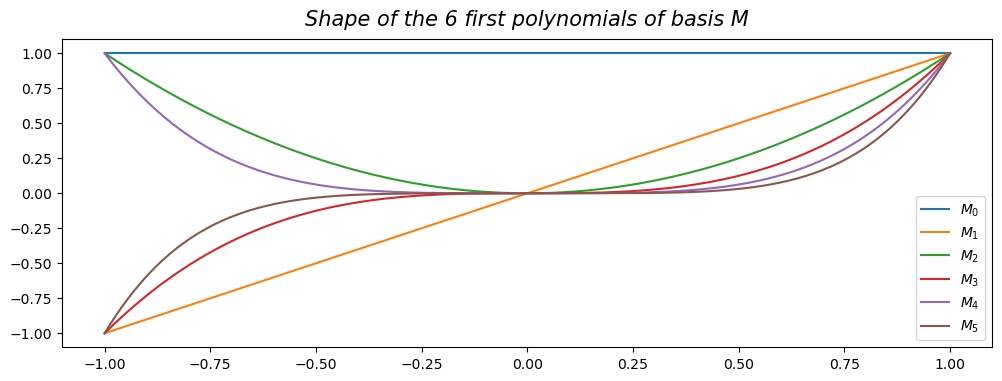

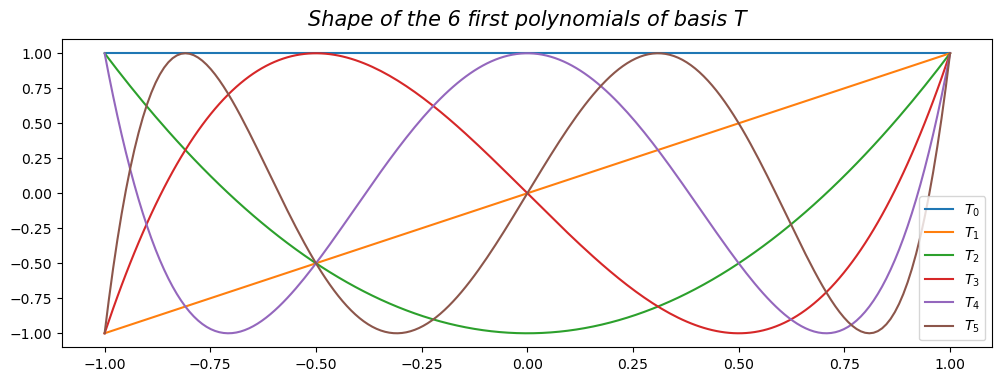

In [11]:
plot_basis(M) # on trace les 6 premiers polynômes de la base des monômes
plot_basis(T) # on trace les 6 premiers polynômes de la base de Chebyshev

---
### 4 - Calcul des approximants polynomiaux

Les classes **`P`** et **`T`** possèdent une méthode **`fit(x, y, n)`** qui permet de calculer le meilleur approximant polynomial de degré $n$ de la fonction $y = f(x)$ en se basant sur les vecteurs d'échantillonnage $x = [x_k]$ et $y = [y_k]$. En utilisant une nouvelle fois la fonction **`plot_funcs`**, écrire une fonction **`plot_fits(name, basis, degrees)`** qui affiche un ensemble d'approximants polynomiaux avec différents degrés, pour une des quatre fonctions de test. Le paramètre **`name`** est la clé identifiant la fonction à approximer dans le dictionnaire **`test_funcs`** défini plus haut, le paramètre **`basis`** correspond à la base polynomiale à utiliser pour l'approximation (**`M`** pour la base monomiale ou **`T`** pour la base de Chebyshev), et le paramètre **`degrees`** est une liste d'entiers définissant les degrés des polynômes à utiliser pour calculer l'approximant.

In [12]:
def plot_fits(name, basis, degrees):
  """plot polynomial approximants for function 'name' using provided 'basis' and 'degrees'"""
  # TODO

Utiliser la fonction **`plot_fits`** pour trouver le degré minimal des polynômes qu'il faut utiliser afin d'obtenir un approximant polynomial qui soit visuellement indifférentiable de la courbe originelle, pour chacune des quatre fonctions de test $f_a, f_b, f_c$ et $f_d$. Tester d'abord avec la base des monômes, puis avec la base de Chebyshev...

In [ ]:
import warnings; warnings.filterwarnings('ignore') # on enlève les 'warning' pour 'poor conditioning'
plot_fits('fa', M, [1,10,11]) # le degré 11 n'est plus différentiable de la fonction initiale
plot_fits('fa', T, [1,10,11]) # idem

In [ ]:
plot_fits('fb', M, [2,26,27]) # le degré 27 n'est plus différentiable de la fonction initiale
plot_fits('fb', T, [2,26,27]) # idem

In [ ]:
plot_fits('fc', M, [1,11,260]) # le degré 260 donne une approximation à peine meilleure que le degré 11
plot_fits('fc', T, [1,11,260]) # le degré 260 n'est plus différentiable de la fonction initiale

In [ ]:
plot_fits('fd', M, [2,27,270]) # le degré 270 donne une approximation à peine meilleure que le degré 27
plot_fits('fd', T, [2,27,270]) # le degré 270 n'est plus différentiable de la fonction initiale 

---
### 5 - Evolution de l'erreur d'approximation en fonction du degré des polynômes

Pour avoir une estimation plus formelle de la qualité des approximants polynomiaux, on va calculer la racine de l'erreur quadratique moyenne (habituellement notée **rmse** pour ***root mean square error***) entre les échantillons de la fonction initiale et ceux de l'approximant, et tracer son évolution en fonction du degré du polynôme utilisé pour l'approximation.

Le package **numpy** ne possède pas de fonction **`rmse`** pour calculer cette différence entre deux vecteurs d'échantillons, mais elle s'écrit de manière triviale :

In [18]:
def rmse(a, b):
  """return root mean square error between two arrays 'a' and 'b'"""
  return np.mean((a-b) ** 2) ** 0.5

Ecrire une fonction **`plot_rmse(name, limit)`** qui va afficher l'évolution de cette **rmse** lorsqu'on fait varier le degré de l'approximant polynomial, en utilisant respectivement la base des monômes et celle de Chebyshev. Le paramètre **`name`** correspond au nom de la fonction à approximer (parmi les 4 fonctions de test) et le paramètre **`limit`** correspond au degré maximum à utiliser. Pour avoir des résultats plus explicites, on utilisera une échelle logarithmique pour l'axe vertical :

In [19]:
def plot_rmse(name, limit):
  """plot RMSE (in log scale) for polynomial approximants of function 'name', up to 'limit' degree"""
  # TODO

On compare la qualité des approximants sur les quatre fonctions de test :

In [ ]:
plot_rmse('fa', 100)

In [ ]:
plot_rmse('fb', 100)

In [ ]:
plot_rmse('fc', 400)

In [ ]:
plot_rmse('fd', 400)

***Que peut-on conclure de ces figures ?***

<h2 style="padding:16px; color:#FFF; background:#07D">E2 - Marches aléatoires</h2>

On souhaite effectuer la simulation de différentes **marches aléatoires** dans un espace discret de dimension 1, 2 ou 3. Pour cela, on va simuler le déplacement d'une particule dans cet espace, dont la position va être modifiée aléatoirement, à chaque étape temporelle, selon une certaine distribution statistique.

Plus précisément, la position de la particule est représentée par une série chronologique $p_n$ définie par :

$$p_0 = d_0 \,,\, p_1 = p_0 + d_1 \,,\, ... \,,\, p_n = p_{n-1} + d_{n} \,,\, ...$$

où $d_n$ correspond à un choix équiprobable parmi un ensemble de déplacements élémentaires, définis sous la forme de listes à valeurs entières. Voici quelques exemples de **listes de déplacements élémentaires** qui seront utilisés pour les simulations mises en oeuvre :

In [25]:
dA, dB, dC, dD, dE, dF = [-1,1], [-2,2], [-1,0,0,0,0,1], [-2,-1,0,1,2], [1,1,1,1,-4], [-2,0,3]
test_disp = dict(dA=dA, dB=dB, dC=dC, dD=dD, dE=dE, dF=dF) # regroupement des listes dans un dictionnaire

> **Note :** Il est important de noter que lorsque la somme des éléments d'une telle liste est nulle, les déplacements vers le haut et vers le bas seront équilibrés, alors que si cette somme n'est pas nulle, l'une des deux directions de déplacement sera privilégiée (en haut pour une somme positive, en bas pour une somme négative)

Pour simplifier la mise en oeuvre de la simulation, on fournit une fonction `plot_walks(walks, title='')` permettant d'afficher un ensemble de marches aléatoires (définies soit par des positions successives, soit par des distances successives) stockées dans un dictionnaire **`walks`**, chacune étant associée à une chaîne de caractères qui sera utilisée comme étiquette pour la légende de la figure. Le vecteur contenant l'échantillonnage temporel (axe horizontal du tracé) n'est pas fourni, mais est calculé directement en fonction de la plus longue des séries chronologiques stockées dans le dictionnaire :

In [26]:
def plot_walks(walks, title=''):
  """plot all random walks stored in 'walks' dict (x-axis = time, y-axis = position or distance)"""
  mp.figure(figsize=(12,4), dpi=100) # set size and precision for figure
  ns = max(walk.size for walk in walks.values()) # nb of steps for longest walk in dictionary
  for name, walk in walks.items(): # loop over all walks stored in dictionary
    mp.plot(np.arange(ns), walk, label=name) # plot current walk and use its name as label
  mp.legend(); mp.title(title, pad=10, fontsize=15, style='italic') # show legend and title on figure

### 1 - Simulation d'une marche aléatoire 1D

Pour simuler une marche aléatoire 1D, il faut créer deux vecteurs avec les outils fournis par **numpy** :
- un vecteur **`d`** contenant la suite de déplacements piochés aléatoirement dans la liste des déplacements
- un vecteur **`p`** contenant la suite de positions, par accumulation des déplacements aléatoires

A partir de ces éléments, écrire une fonction **`random_walk(name, ns)`** qui renvoit le vecteur **`p`** de la suite des positions, en piochant aléatoirement chaque déplacement dans la liste **`name`** stockée dans le dictionnaire **`test_disp`** défini ci-dessus. Le paramètre **`ns`** (***number of steps***) correspond au nombre d'étapes temporelles à utiliser pour générer les positions :

In [27]:
def random_walk(name, ns):
  """return a vector of 'ns' random positions, using walk steps based on displacement list 'name'"""
  # TODO

On affiche les marches aléatoires obtenues avec différentes configurations pour **`name`** et **`ns`** :

In [ ]:
name, ns = 'dA', 200; # changer les valeurs pour tester différentes configurations
plot_walks({name:random_walk(name, ns)}, f"random walk, using {ns} steps from {name}")

### 2 - Simulation d'une séquence de marches aléatoires 1D

Pour effectuer la simulation de plusieurs marches aléatoires avec les mêmes paramètres, il suffit de créer une matrice de déplacements aléatoires (au lieu d'un vecteur) et d'accumuler les déplacements le long des colonnes de cette matrice. Ecrire une fonction **`random_walks(name, ns, nw)`** qui implémente ce principe : par rapport à **`random_walk`**, on rajoute simplement le paramètre **`nw`** (***number of walks***) permettant de choisir le nombre de marches aléatoires à simuler :

In [30]:
def random_walks(name, ns, nw):
  """return a matrix of 'nw'x'ns' random positions, using walk steps based on displacement list 'name'"""
  # TODO

On affiche les marches aléatoires obtenues avec différentes configurations pour **`name`**, **`ns`** et **`nw`** :

In [ ]:
name, ns, nw = 'dC', 2000, 10 # changer les valeurs pour tester différentes configurations
walks = random_walks(name, ns, nw)
plot_walks(dict(zip(range(nw), walks)), f"{nw} random walks, using {ns} steps from {name}")

### 3 - Position moyenne et distance moyenne parcourue

La propriété remarquable des marches aléatoires 1D s'observe en calculant et en comparant, sur un grand nombre de simulations, la ***position moyenne de la particule*** et la ***distance moyenne parcourue par la particule*** au cours du temps.

Ecrire la suite d'instructions permettant de créer une variable **`position`** stockant le vecteur des positions moyennes, et une variable **`distance`** stockant le vecteur des distances moyennes parcourue (à nouveau, on utilisera les variables **`name`**, **`ns`** et **`nw`** pour spécifier différentes configurations). Afficher les vecteurs **`position`** et **`distance`** sur la même figure, en utilisant la fonction **`plot_walks`** :

In [33]:
name, ns, nw = 'dA', 2000, 10000 # changer les valeurs pour tester différentes configurations
# TODO

### 4 - Carré de la distance moyenne parcourue

Pour toute marche aléatoire 1D dont les déplacements sont piochés dans une liste à somme nulle, ***le carré de la distance moyenne parcourue est proportionnel au nombre d'étapes temporelles***. Ce résultat n'est pas valide si la somme des éléments de la liste des déplacements élémentaires n'est pas nulle.

Ecrire la séquence d'instructions permettant une vérification expérimentale de ce résultat pour chacune de nos listes de test **`dA`**, **`dB`**, **`dC`**, **`dD`**, **`dE`** (à somme nulle) et **`dF`** (à somme non nulle) :

In [35]:
distances, ns, nw = {}, 2000, 10000 # nombre de pas et nombre de marches
# TODO

### 5 - Simulation d'une marche aléatoire 2D

Pour simuler une marche aléatoire 2D, il y a deux approches possibles pour définir le problème à résoudre :

- soit on considère que les déplacements aléatoires sur chacun des 2 axes sont des processus indépendants, ce qui revient à dire qu'une marche aléatoire 2D est simplement la combinaison de 2 marches aléatoires 1D : l'une fournit les positions sur l'axe $x$ et l'autre les positions sur l'axe $y$

- soit on considère que les déplacements aléatoires sur les 2 axes sont des processus liés, et dans ce cas, il faut fournir une liste de déplacements élémentaires composés de couples $(dx,dy)$

La seconde approche est en fait un sur-ensemble de la première (pour simuler la première approche avec la seconde, il suffit de définir la liste des couples comme le produit cartésien des listes de déplacement sur les 2 axes). Pour des raisons de simplicité, on va traiter uniquement la première approche dans cet exercice (la mise en oeuvre de la seconde approche est laissée en travail personnel).

Ecrire une fonction **`plot_walk2D(xname, yname, ns)`** qui permet de générer et d'afficher une marche aléatoire 2D de **`ns`** étapes temporelles, en utilisant la liste **`xname`** (resp. **`yname`**) pour le choix des déplacements aléatoires en $x$ (resp. $y$). On forcera la figure à utiliser la même échelle pour les axes $x$ et $y$ afin de ne pas déformer le tracé :

In [37]:
def plot_walk2D(xname, yname, ns):
  """generate and plot a 2D random walk, using 'ns' steps from 'xname' and 'yname' displacement lists"""
  # TODO

On affiche les marches aléatoires 2D obtenues avec différentes configurations pour **`xname`**, **`yname`** et **`ns`** :

In [ ]:
xname, yname, ns = 'dB', 'dE', 1000 # changer les valeurs pour tester différentes configurations
plot_walk2D(xname, yname, ns)

Ecrire la suite d'instructions permettant de vérifier expérimentalement que le résultat sur le carré de la distance moyenne est également valable pour les marches aléatoires 2D (on testera le résultat sur quelques combinaisons **`xname`** et **`yname`**) :

In [40]:
distances, ns, nw = {}, 2000, 10000 # nombre de pas et nombre de marches
# TODO

### 6 - Simulation d'une marche aléatoire 3D

Pour simuler une marche aléatoire 3D, on retrouve les deux mêmes approches possibles, selon que l'on considère les déplacements sur les 3 axes comme des processus indépendants ou non. A nouveau on va se limiter à la première approche pour simplifier l'implémentation.

Il s'agit donc d'écrire une fonction **`plot_walk2D(xname, yname, zname, ns)`** qui permet de générer et d'afficher une marche aléatoire 3D de **`ns`** étapes temporelles, en utilisant la liste **`xname`** (resp. **`yname`** et **`zname`**) pour le choix des déplacements aléatoires en $x$ (resp. $y$ et $z$). On utilisera évidemment une projection 3D pour le tracé :

In [42]:
def plot_walk3D(xname, yname, zname, ns):
  """generate and plot a 3D random walk, using 'ns' steps from 'xname,yname,zname' displacement lists"""
  # TODO

On affiche les marches aléatoires 3D obtenues avec différentes configurations pour **`xname`**, **`yname`**, **`zname`** et **`ns`** :

In [ ]:
xname, yname, zname, ns = 'dC', 'dC', 'dC', 1000 # changer les valeurs pour tester différentes configurations
plot_walk3D(xname, yname, zname, ns)

Enfin, écrire la suite d'instructions permettant de vérifier expérimentalement que le résultat sur le carré de la distance moyenne est également valable pour les marches aléatoires 3D (on testera le résultat sur quelques combinaisons aléatoirement choisies pour **`xname`**, **`yname`** et **`zname`**) :

In [45]:
distances, ns, nw = {}, 2000, 5000 # nombre de pas et nombre de marches
# TODO

---